# Principal geodesic analysis and spectral decomposition

In [1]:
import os
import sys
from pathlib import Path
sys.path.append(str(Path(os.getcwd()).parent.absolute()))

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from pca.bures_wasserstein_principal_geodesic_analysis import BuresWassersteinPGA
from tools.plot_2d import plot_results
from tools.compute import make_rotation_2d

## PGA on SPD matrices that are diagonalizable in the same orthonormal basis

We randomly generate diagonal SPD matrices.

In [7]:
n_points = 100
seig_1 = np.random.uniform(high=5, size=n_points)
seig_2 = np.random.uniform(high=3, size=n_points)
eig_1 = seig_1 ** 2
eig_2 = seig_2 ** 2
points_spd = np.stack([np.diag([eig_1i, eig_2i]) for (eig_1i, eig_2i) in zip(eig_1, eig_2)])

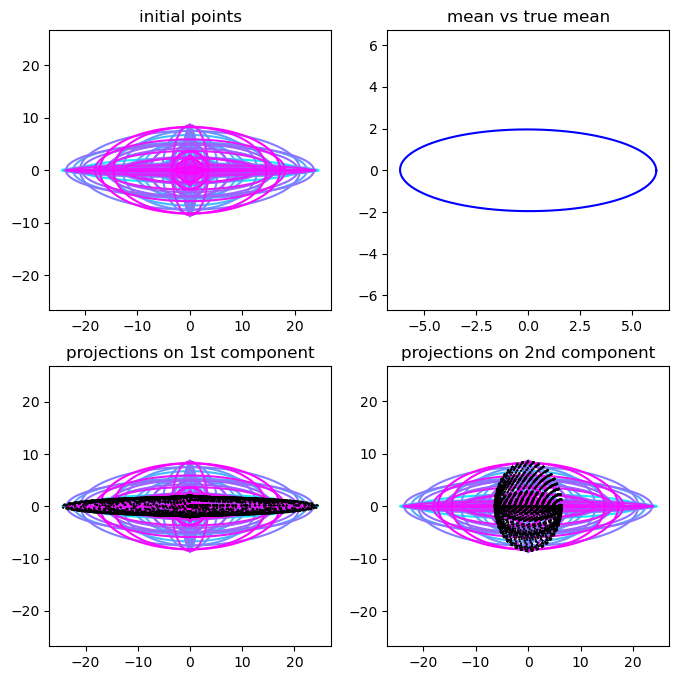

In [8]:
pga = BuresWassersteinPGA(dim=2).fit(points_spd)
plot_results(points_spd, pga)

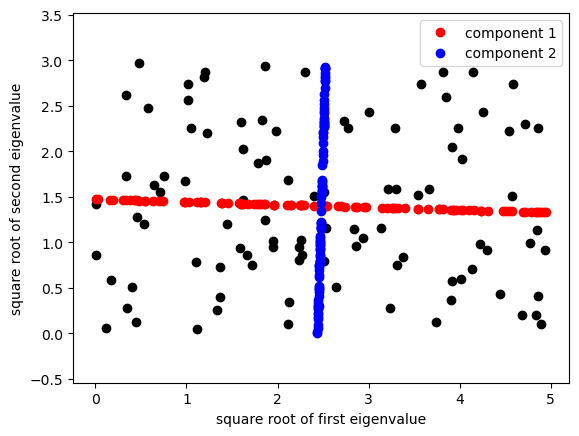

In [9]:
eig_comp1 = np.vstack([np.linalg.eig(mat)[0] for mat in pga['component_1']])
eig_comp2 = np.vstack([np.linalg.eig(mat)[0] for mat in pga['component_2']])

plt.plot(np.sqrt(eig_1), np.sqrt(eig_2), 'ok')
plt.plot(np.sqrt(eig_comp1[:, 0]), np.sqrt(eig_comp1[:, 1]), 'or', label='component 1')
plt.plot(np.sqrt(eig_comp2[:, 0]), np.sqrt(eig_comp2[:, 1]), 'ob', label='component 2')
plt.axis('equal')
plt.legend()
plt.xlabel('square root of first eigenvalue')
plt.ylabel('square root of second eigenvalue')
plt.show()

## PGA on SPD matrices that have the same eigenvalues

We randomly generate SPD matrices with the same eigenvalues.

In [10]:
np.random.seed(1)

eig_1 = np.random.uniform(high=10)
eig_2 = np.random.uniform(high=10)
print(eig_1, eig_2)

4.17022004702574 7.203244934421581


In [11]:
angles = np.random.uniform(high=2 * np.pi, size=n_points)
rotations = make_rotation_2d(angles)
diag_mat = np.diag([eig_1, eig_2])
points_spd = np.stack([rot @ diag_mat @ rot.T for rot in rotations])

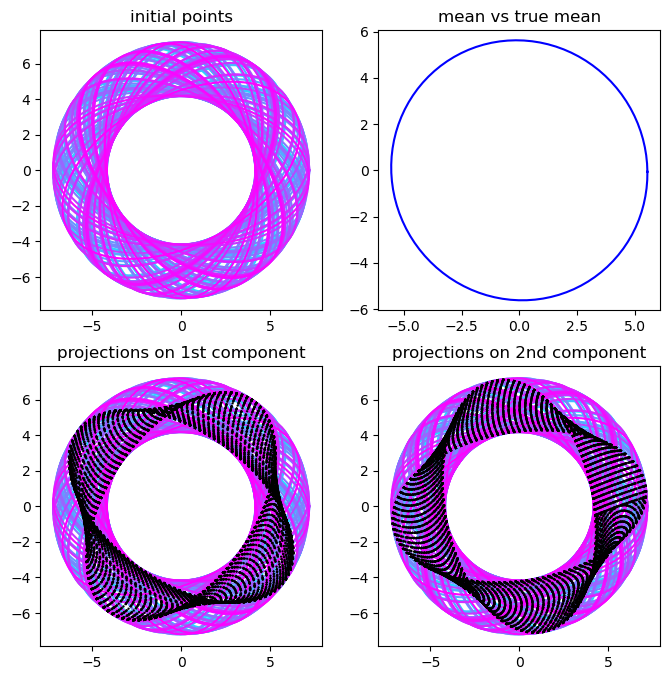

In [12]:
pga = BuresWassersteinPGA(dim=2).fit(points_spd)
plot_results(points_spd, pga)

## Detection of eigenvalue and rotation variations by the principal components

In [13]:
def spectral_decomposition(mat):
    eig, rot = np.linalg.eigh(mat)
    if np.sum(rot > 0.) == 1:
        rot *= -1
    angle = np.arccos(rot[0, 0])
    return eig, angle

def pga_with_respect_to_spectral_decomposition(n_points, eig_min, eig_max, angle_min, angle_max, seed=None):
    if seed is not None: np.random.seed(seed)

    eig = np.random.uniform(low=eig_min, high=eig_max, size=n_points)
    angles = np.random.uniform(low=angle_min, high=angle_max, size=n_points)
    rotations = make_rotation_2d(angles)
    
    coef = 2
    diag_mats = np.stack([np.diag([eig_i, coef * eig_i]) for eig_i in eig])
    points_spd = np.stack([rot @ diag_mat @ rot.T for (rot, diag_mat) in zip(rotations, diag_mats)])
    
    pca = BuresWassersteinPGA(2).fit(points_spd)
    plot_results(points_spd, pca)

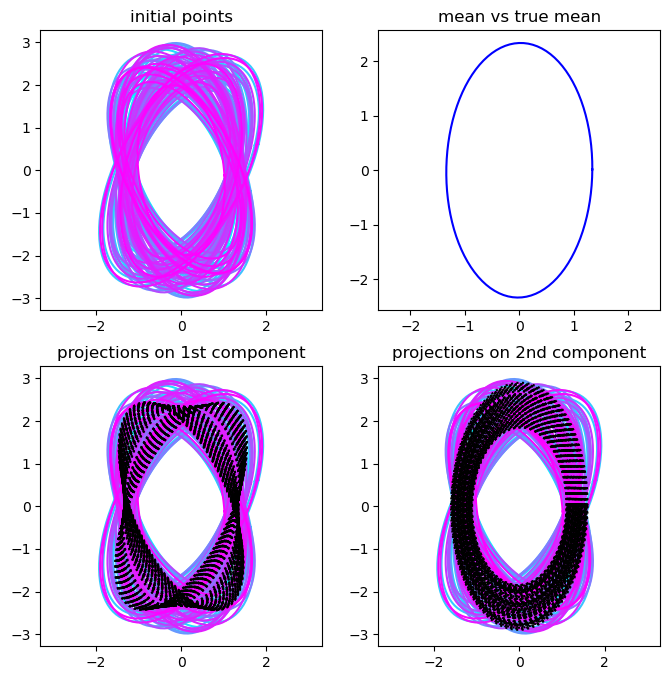

In [14]:
pga_with_respect_to_spectral_decomposition(
    n_points=100, 
    eig_min=1., 
    eig_max=1.5, 
    angle_min=-np.pi/6, 
    angle_max=np.pi/6,
    seed=1,
)

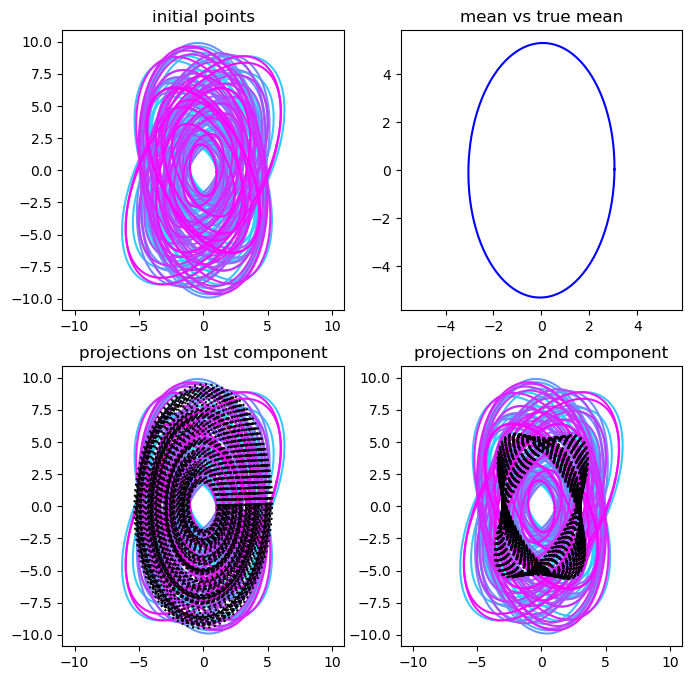

In [15]:
pga_with_respect_to_spectral_decomposition(
    n_points=100, 
    eig_min=1., 
    eig_max=5., 
    angle_min=-np.pi/6, 
    angle_max=np.pi/6,
    seed=1,
)